In this notebook, I will provide an overview of the dataset, perform cleaning and formatting based on the assumption checks conducted in 02_assumptions.ipynb, and saving it into a parquet format prior to performing the exploratory data analysis (EDA).

In [1]:
import pandas as pd
import os
import seaborn as sns 
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
df_raw = pd.read_csv("../data/raw/ncr_ride_bookings.csv")


In [3]:
df_raw.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
df_raw.info(memory_usage = "deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

I have a list of to-do's from the previous notebook:
 
1. Convert names into snake case
2. Map target variable 
3. Remove data leakage
4. Format Booking ID and Customer ID
5. Recast columns 


## Convert names into snake case

In [5]:
import re 
df_columns_clean = df_raw.copy()
def to_snake_case(df):
    new_columns = []
    for col in df.columns:
        col = col.strip()
        col = re.sub(r'[\s\-]+', '_', col)
        col = re.sub(r'[^\w_]', '', col)
        col = col.lower()
        new_columns.append(col)
    
    df.columns = new_columns
    return df

df_columns_clean = to_snake_case(df_columns_clean)
print(df_columns_clean.columns.tolist())

['date', 'time', 'booking_id', 'booking_status', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat', 'avg_ctat', 'cancelled_rides_by_customer', 'reason_for_cancelling_by_customer', 'cancelled_rides_by_driver', 'driver_cancellation_reason', 'incomplete_rides', 'incomplete_rides_reason', 'booking_value', 'ride_distance', 'driver_ratings', 'customer_rating', 'payment_method']


## Map target variable

In [6]:
df_target_mapped = df_columns_clean.copy()

booking_mapping = {
    "Completed": 0,
    "Cancelled by Driver": 1,
    "No Driver Found": 1,
    "Cancelled by Customer": 1,
    "Incomplete": 0
}

df_target_mapped['is_cancelled'] = df_target_mapped['booking_status'].map(booking_mapping)
del df_target_mapped["booking_status"]
df_target_mapped['is_cancelled'].value_counts()

is_cancelled
0    102000
1     48000
Name: count, dtype: int64

## Remove data leakage

Leaking columns: 
- Cancelled Rides by Driver
- Cancelled Rides by Customer
- Reason for cancelling by Customer
- Driver Cancellation Reason
- Incomplete Rides
- Incomplete Rides Reason
- Driver Ratings
- Customer Rating

In [7]:
df_leak_clean = df_target_mapped.copy()

df_leak_clean.drop(columns = ["cancelled_rides_by_customer",
                                "reason_for_cancelling_by_customer",
                                "cancelled_rides_by_driver",
                                "driver_cancellation_reason",
                                "incomplete_rides",
                                "incomplete_rides_reason",
                                "driver_ratings",
                                "customer_rating"], inplace = True)

df_leak_clean.shape[0], df_leak_clean.shape[1]

(150000, 13)

## Format Booking ID and Customer ID

In [8]:
df_clean_quotes = df_leak_clean.copy()

cols_with_quotes = ["booking_id", 
                    "customer_id"]

for col in cols_with_quotes:
    df_clean_quotes[col] = df_clean_quotes[col].str.strip('"')

df_clean_quotes[["booking_id", 
                    "customer_id"]]

,booking_id,customer_id
0,CNR5884300,CID1982111
1,CNR1326809,CID4604802
2,CNR8494506,CID9202816
3,CNR8906825,CID2610914
4,CNR1950162,CID9933542
...,...,...
149995,CNR6500631,CID4337371
149996,CNR2468611,CID2325623
149997,CNR6358306,CID9925486
149998,CNR3030099,CID9415487


## Recast columns

In [9]:
df_typed = df_clean_quotes.copy()

df_typed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             150000 non-null  object 
 1   time             150000 non-null  object 
 2   booking_id       150000 non-null  object 
 3   customer_id      150000 non-null  object 
 4   vehicle_type     150000 non-null  object 
 5   pickup_location  150000 non-null  object 
 6   drop_location    150000 non-null  object 
 7   avg_vtat         139500 non-null  float64
 8   avg_ctat         102000 non-null  float64
 9   booking_value    102000 non-null  float64
 10  ride_distance    102000 non-null  float64
 11  payment_method   102000 non-null  object 
 12  is_cancelled     150000 non-null  int64  
dtypes: float64(4), int64(1), object(8)
memory usage: 14.9+ MB


### Temporal features

Converting column `date` and `time` would add unnecessary complexity so I will merge them into datetime later. 

### Categorical
1. Columns with "object" data type and no nulls are directly turned into Category
   
2. Columns with "object" data type and nulls are turned into Category based on threshold. Threshold is set to 0.5, that means less than 50% of values are unique. If threshold is less that this value, the column will be turned into string[pyarrow] type. 

In [10]:
cat_ambiguous = ["booking_id", 
               "customer_id" ]
cat_threshold = 0.5

for col in cat_ambiguous:
    if col in df_typed.columns:
        num_unique = df_typed[col].nunique(dropna = False)
        ratio_unique = num_unique/len(df_typed)

        if ratio_unique <= cat_threshold:
            df_typed[col] = df_typed[col].astype("category")
            print(f"- Column {col} has been transformed into Category")
            print(f"Ratio of the column: {ratio_unique:.4%}")
        else:
            df_typed[col] = df_typed[col].astype("string[pyarrow]")
            print(f"- Column {col} has been transformed into string[pyarrow]")
            print(f"Ratio of the column: {ratio_unique:.4%}")


- Column booking_id has been transformed into string[pyarrow]
Ratio of the column: 99.1780%
- Column customer_id has been transformed into string[pyarrow]
Ratio of the column: 99.1920%


In [11]:
cat_columns = ["vehicle_type", 
               "pickup_location", 
               "drop_location",
               "payment_method"]

for col in cat_columns:
    if col in df_typed.columns:
        df_typed[col] = df_typed[col].astype("category")
        print(f"- Column {col} has been transformed into Category")

- Column vehicle_type has been transformed into Category
- Column pickup_location has been transformed into Category
- Column drop_location has been transformed into Category
- Column payment_method has been transformed into Category


### Numerical

i usually perform type optimization since I'm working on my personal computer. In this case, since the dataset is not very big, I will only transform the numerical data into float32

In [12]:
numerical_columns = ["avg_vtat", 
                 "avg_ctat", 
                 "booking_value",
                 "ride_distance",
                 "is_cancelled"]

for col in numerical_columns:
    if col in df_typed.columns:
        df_typed[col] = df_typed[col].astype("float32")
        print(f"- Column {col} has been transformed into float32")


- Column avg_vtat has been transformed into float32
- Column avg_ctat has been transformed into float32
- Column booking_value has been transformed into float32
- Column ride_distance has been transformed into float32
- Column is_cancelled has been transformed into float32


In [13]:
df_typed.to_parquet("../data/bronze/clean_dataset.parquet",  engine='fastparquet', index=False)

## Data Profiling

In [14]:
data = df_typed.copy()
data = data.sort_values(["date", "time"]).reset_index(drop=True)

In [15]:
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [16]:
data.tail()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
149995,2024-12-30,22:58:00,CNR9030698,CID6939658,Bike,DLF Phase 3,Okhla,6.9,35.799999,440.0,12.850000,UPI,0.0
149996,2024-12-30,23:03:14,CNR1507833,CID9905090,eBike,Saket,Noida Sector 62,7.9,33.599998,279.0,39.360001,UPI,0.0
149997,2024-12-30,23:17:05,CNR2265113,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,9.9,39.900002,1855.0,38.910000,UPI,0.0
149998,2024-12-30,23:21:12,CNR4066733,CID8938559,Uber XL,Ashram,Vasant Kunj,2.6,26.700001,520.0,36.369999,Uber Wallet,0.0
149999,2024-12-30,23:36:11,CNR6915581,CID5185745,Auto,Pitampura,Nehru Place,3.5,11.900000,571.0,2.670000,UPI,0.0


In [17]:
import numpy as np

stats = data.describe(include='all')
stats.loc['dtype'] = data.dtypes
stats.loc['rows_dataset'] = len(data)

stats.loc['n_missing'] = data.isna().sum()
stats.loc['% missing'] = data.isna().sum() * 100

numeric_cols = data.select_dtypes(include=np.number).columns
if len(numeric_cols) > 0:
    stats.loc['skew', numeric_cols] = data[numeric_cols].skew()
    stats.loc['kurtosis', numeric_cols] = data[numeric_cols].kurtosis()
    stats.loc['range', numeric_cols] = data[numeric_cols].max() - data[numeric_cols].min()
    stats.loc['iqr', numeric_cols] = data[numeric_cols].quantile(0.75) - data[numeric_cols].quantile(0.25)

stats

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
count,150000,150000,150000,150000,150000,150000,150000,139500.0,102000.0,102000.0,102000.0,102000,150000.0
unique,365,62910,148767,148788,7,176,176,NaN,NaN,NaN,NaN,5,NaN
top,2024-11-16,17:44:57,CNR9603232,CID4523979,Auto,Khandsa,Ashram,NaN,NaN,NaN,NaN,UPI,NaN
freq,462,16,3,3,37419,949,936,NaN,NaN,NaN,NaN,45909,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456351,29.149632,508.295929,24.637012,NaN,0.32
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,395.805756,14.002138,NaN,0.466478
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,50.0,1.0,NaN,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3,21.6,234.0,12.46,NaN,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.3,28.799999,414.0,23.719999,NaN,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.3,36.799999,689.0,36.82,NaN,1.0


## Univariate Analysis


### date

- What is the distribution of the column? 
- Is there any clear pattern? 
- What is the cardinality?
- Outliers? Missing values?

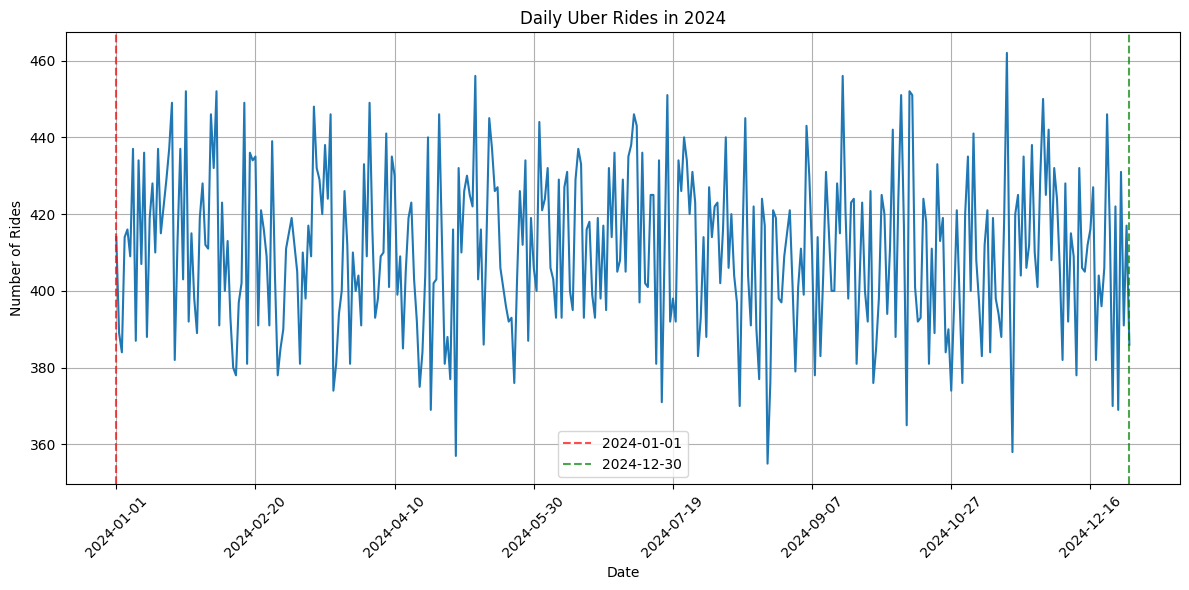

In [18]:
plt.figure(figsize=(12, 6))
daily_counts = data.groupby('date').size()
plt.plot(daily_counts.index, daily_counts.values)

first_date = daily_counts.index.min()
last_date = daily_counts.index.max()
first_date_label = daily_counts.index.min()
last_date_label = daily_counts.index.max()
plt.axvline(first_date, color='red', linestyle='--', alpha=0.7, label=first_date_label)
plt.axvline(last_date, color='green', linestyle='--', alpha=0.7, label=last_date_label)
plt.title('Daily Uber Rides in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Rides')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



how can I have 365 unique values if the 31st of Dec does not appear? Maybe there is a 29th of Feb? 

In [21]:
data[data["date"] == "2024-02-29"].head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
24403,2024-02-29,00:00:09,CNR2330207,CID8309113,Auto,Kirti Nagar,Sonipat,9.3,NaN,NaN,NaN,NaN,1.0
24404,2024-02-29,00:08:57,CNR6004216,CID5184316,Go Mini,Meerut,Ghitorni Village,2.8,21.799999,621.0,6.470000,Credit Card,0.0
24405,2024-02-29,00:24:06,CNR1464111,CID1168333,Premier Sedan,Malviya Nagar,Udyog Vihar,3.2,20.200001,444.0,28.160000,Cash,0.0
24406,2024-02-29,00:36:19,CNR3852671,CID4695190,Premier Sedan,Malviya Nagar,Connaught Place,NaN,NaN,NaN,NaN,NaN,1.0
24407,2024-02-29,01:10:18,CNR9446862,CID3841042,Bike,Okhla,Sarojini Nagar,3.7,25.400000,362.0,37.630001,Credit Card,0.0


I cannot see a clear pattern, let's see with "time"

### time

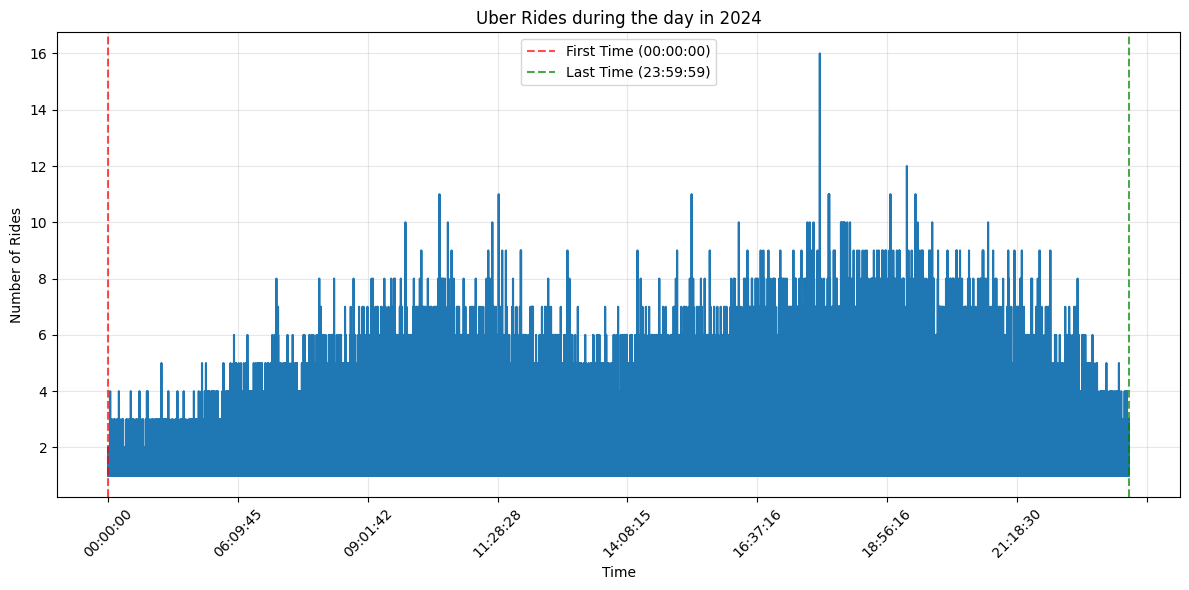

In [22]:
plt.figure(figsize=(12, 6))

time_counts = data.groupby('time').size().sort_index()
plt.plot(time_counts.index, time_counts.values)

first_time = time_counts.index.min()
last_time = time_counts.index.max()
plt.axvline(first_time, color='red', linestyle='--', alpha=0.7, label=f'First Time ({first_time})')
plt.axvline(last_time, color='green', linestyle='--', alpha=0.7, label=f'Last Time ({last_time})')


plt.title('Uber Rides during the day in 2024')
plt.xlabel('Time')
plt.ylabel('Number of Rides')


plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
time_counts[time_counts > 15]

time
17:44:57    16
dtype: int64

Interesting finding, since time also considers the seconds, it could be an outlier or a technical error (the system failed and then processed all the delayed trips in that second?) or maybe it could be a coincidence. Let's see the ones around

In [35]:
high_counts = time_counts[(time_counts.index > '17:44:45') & (time_counts.index < '17:45:10')]

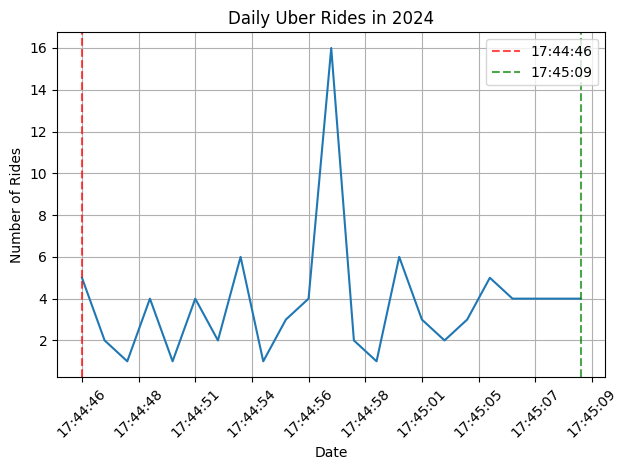

In [37]:
plt.plot(high_counts.index, high_counts.values)

first_date = high_counts.index.min()
last_date = high_counts.index.max()
first_date_label = high_counts.index.min()
last_date_label = high_counts.index.max()
plt.axvline(first_date, color='red', linestyle='--', alpha=0.7, label=first_date_label)
plt.axvline(last_date, color='green', linestyle='--', alpha=0.7, label=last_date_label)
plt.title('Daily Uber Rides in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Rides')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


There is no clear pattern it's a coincidence but it's always nice to contrast with other sources but I will treat it as an outlier if necessary

Let's create a datetime column by merging date and time

In [40]:
data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'])

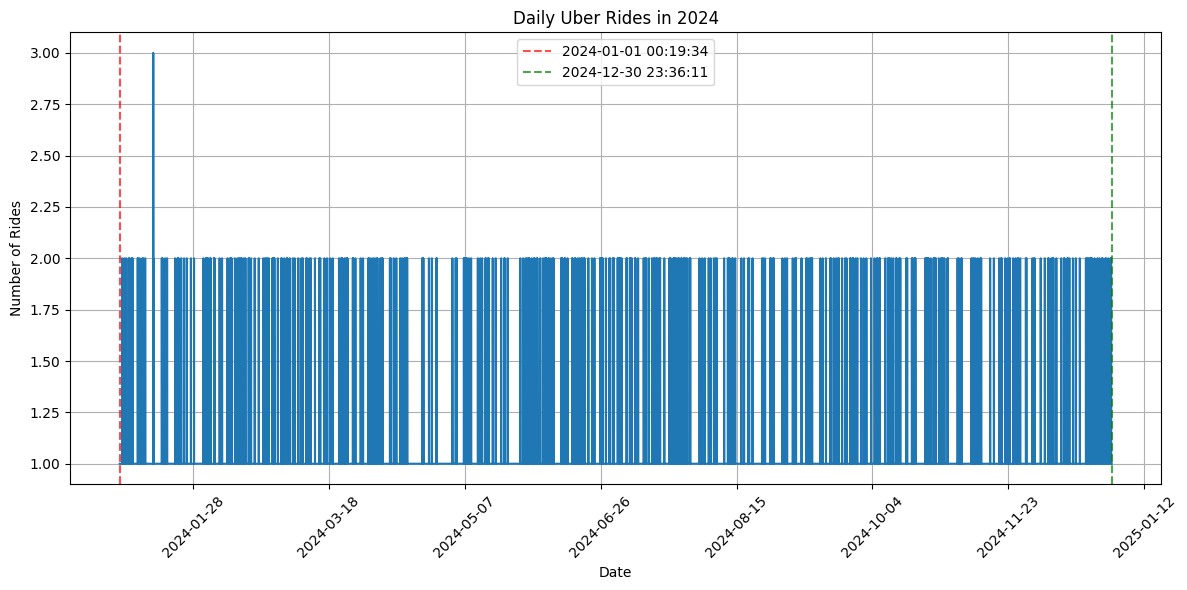

In [41]:
plt.figure(figsize=(12, 6))
daily_counts = data.groupby('datetime').size()
plt.plot(daily_counts.index, daily_counts.values)

first_date = daily_counts.index.min()
last_date = daily_counts.index.max()
first_date_label = daily_counts.index.min()
last_date_label = daily_counts.index.max()
plt.axvline(first_date, color='red', linestyle='--', alpha=0.7, label=first_date_label)
plt.axvline(last_date, color='green', linestyle='--', alpha=0.7, label=last_date_label)
plt.title('Daily Uber Rides in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Rides')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
daily_counts[daily_counts > 2]

datetime
2024-01-13 09:16:53    3
dtype: int64

This is too much to handle, I gonna break it down into other columns

In [ ]:
# DO AVERAGE OF TIME COLUMN, 
# DO DATETIME INTO MONTH, DAY OF THE WEEK, IS WEEKEND, HOUR, MORNING OR AFTERNOON OR NIGHT 

#### Categorical

In [ ]:
pd.set_option("display.max_rows", None)
cat_cols = df_typed.select_dtypes(include="category").columns


In [ ]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df_typed[col].value_counts(dropna=False))


### String

In [ ]:
string_cols = df_typed.select_dtypes(include="string[pyarrow]").columns


In [ ]:
for col in string_cols:
    print(f"\n=== {col} ===")
    print(df_typed[col].value_counts(dropna=False))

### Numerical

In [ ]:
df_typed.describe()

In [ ]:
df_typed.hist(figsize=(20, 15), bins = 100)

## Train/test split

The dataset goes from the 1st of January 2024 to the 30th December 2024, I will split it following 75% train, 15% val, 10% test.

In [ ]:
df_typed = df_typed.sort_values("date")

train_end = "2024-09-30"  
val_end = "2024-11-30"

train_df = df_typed[df_typed["date"] <= train_end]
val_df   = df_typed[(df_typed["date"] > train_end) & (df_typed["date"] <= val_end)]
test_df  = df_typed[df_typed["date"] > val_end]

In [ ]:
print(f" Train: {len(train_df)}")
print(f" Validation : {len(val_df)}")
print(f" Test: {len(test_df)}")

## Save dataset splits

In [ ]:
output_dir = "../data/bronze"
os.makedirs(output_dir, exist_ok=True)  
df_typed.to_parquet(os.path.join(output_dir, "dataset.parquet"), index=False)
train_df.to_parquet(os.path.join(output_dir, "train.parquet"), index=False)
val_df.to_parquet(os.path.join(output_dir, "val.parquet"), index=False)
test_df.to_parquet(os.path.join(output_dir, "test.parquet"), index=False)